# Composite ROME Layer Detector — Visualization

This notebook visualizes the v5c composite detector results:
- Per-model signal profiles (spectral_gap, top1_energy, local z-scores)
- Summary accuracy across all models
- Method breakdown per model
- Top-K sensitivity analysis

In [6]:
from pathlib import Path
import sys, json, os

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib-cache")))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# Make imports/data paths work whether the notebook is launched from the
# repository root or from detector/.
cwd = Path.cwd().resolve()
if (cwd / "detector" / "composite_detector_v2.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "detector" / "composite_detector_v2.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.modules.pop("composite_detector_v2", None)
sys.modules.pop("detector.composite_detector_v2", None)

from detector.composite_detector_v2 import (
    local_zscore, _curvature, detect_layer, process_file,
    plot_signal_profiles, plot_summary_table, plot_method_breakdown,
    _collect_json_files
)

# Notebook controls. Defaults process your selected detector subset.
# Examples:
#   MODEL_FILTER = []
#   MODEL_FILTER = ["qwen3-4b"]
#   MAX_RUNS = 3
#   MAX_TESTS_PER_RUN = 5
MODEL_FILTER = ['qwen3-8b']  # Case-insensitive substrings; [] means all models.
MAX_RUNS = None              # Limit number of structural JSON files; None means all.
MAX_TESTS_PER_RUN = 3        # Limit valid tests per JSON file; None means all.
RUN_TOPK_ANALYSIS = False    # Top-K analysis is slower; enable when needed.
TRIM = 2


def _matches_model(path):
    if not MODEL_FILTER:
        return True
    text = Path(path).stem.lower()
    return any(model.lower() in text for model in MODEL_FILTER)

## 1. Run detector on all models

In [7]:
data_dirs = []
for d in ["ultrasupertest", "results_n5"]:
    path = PROJECT_ROOT / d
    if path.exists():
        data_dirs.append(str(path))

json_files = [jf for jf in _collect_json_files(data_dirs) if _matches_model(jf)]
if MAX_RUNS is not None:
    json_files = json_files[:MAX_RUNS]
print(f"Found {len(json_files)} structural JSON files")

all_results = []
for i, jf in enumerate(json_files, 1):
    print(f"[{i}/{len(json_files)}] Processing {Path(jf).name}")
    result = process_file(jf, trim=TRIM, max_tests=MAX_TESTS_PER_RUN)
    all_results.append(result)

total_c = sum(r["correct"] for r in all_results)
total_t = sum(r["n_tests"] for r in all_results)
if total_t:
    print(f"\nOverall: {total_c}/{total_t} ({total_c/total_t:.1%})")
else:
    print("\nOverall: 0/0 (no matching tests)")

# Print per-model summary
for r in all_results:
    short = r["model"].split("/")[-1] if "/" in r["model"] else r["model"]
    mc = ", ".join(f"{k}:{v}" for k, v in
                   sorted(r["method_counts"].items(), key=lambda x: -x[1]))
    flag = "✓" if r["accuracy"] >= 0.9 else ("✗" if r["accuracy"] < 0.5 else "~")
    print(f"  {short:<30s} L{r['target_layer']:>2d}  "
          f"{r['correct']:>2}/{r['n_tests']:<2d} {r['accuracy']:>4.0%}  {mc} {flag}")

Found 2 structural JSON files
[1/2] Processing rome_structural_qwen3-8b_tk50_tfauto_tlauto_nl1_rw5_lw3-5-7_s01_r01_2026-04-13_16-38-14.json
[2/2] Processing rome_structural_qwen3-8b_tk50_tfauto_tlauto_nl1_rw5_lw3-5-7_s01_r01_2026-04-17_13-47-19.json

Overall: 6/6 (100.0%)
  Qwen3-8B                       L10   3/3  100%  te(lz5):3 ✓
  Qwen3-8B                       L10   3/3  100%  te(lz5):3 ✓


## 2. Signal Profiles (per model)

Each plot shows 4 signals across layers for the first test of each model:
- **SG (raw)**: spectral gap = σ₁/σ₂
- **TE (lz5)**: |local z-score| of top1_energy with window=5
- **SG (lz5)**: |local z-score| of spectral_gap with window=5
- **SG (lz7)**: |local z-score| of spectral_gap with window=7

### Qwen3-8B

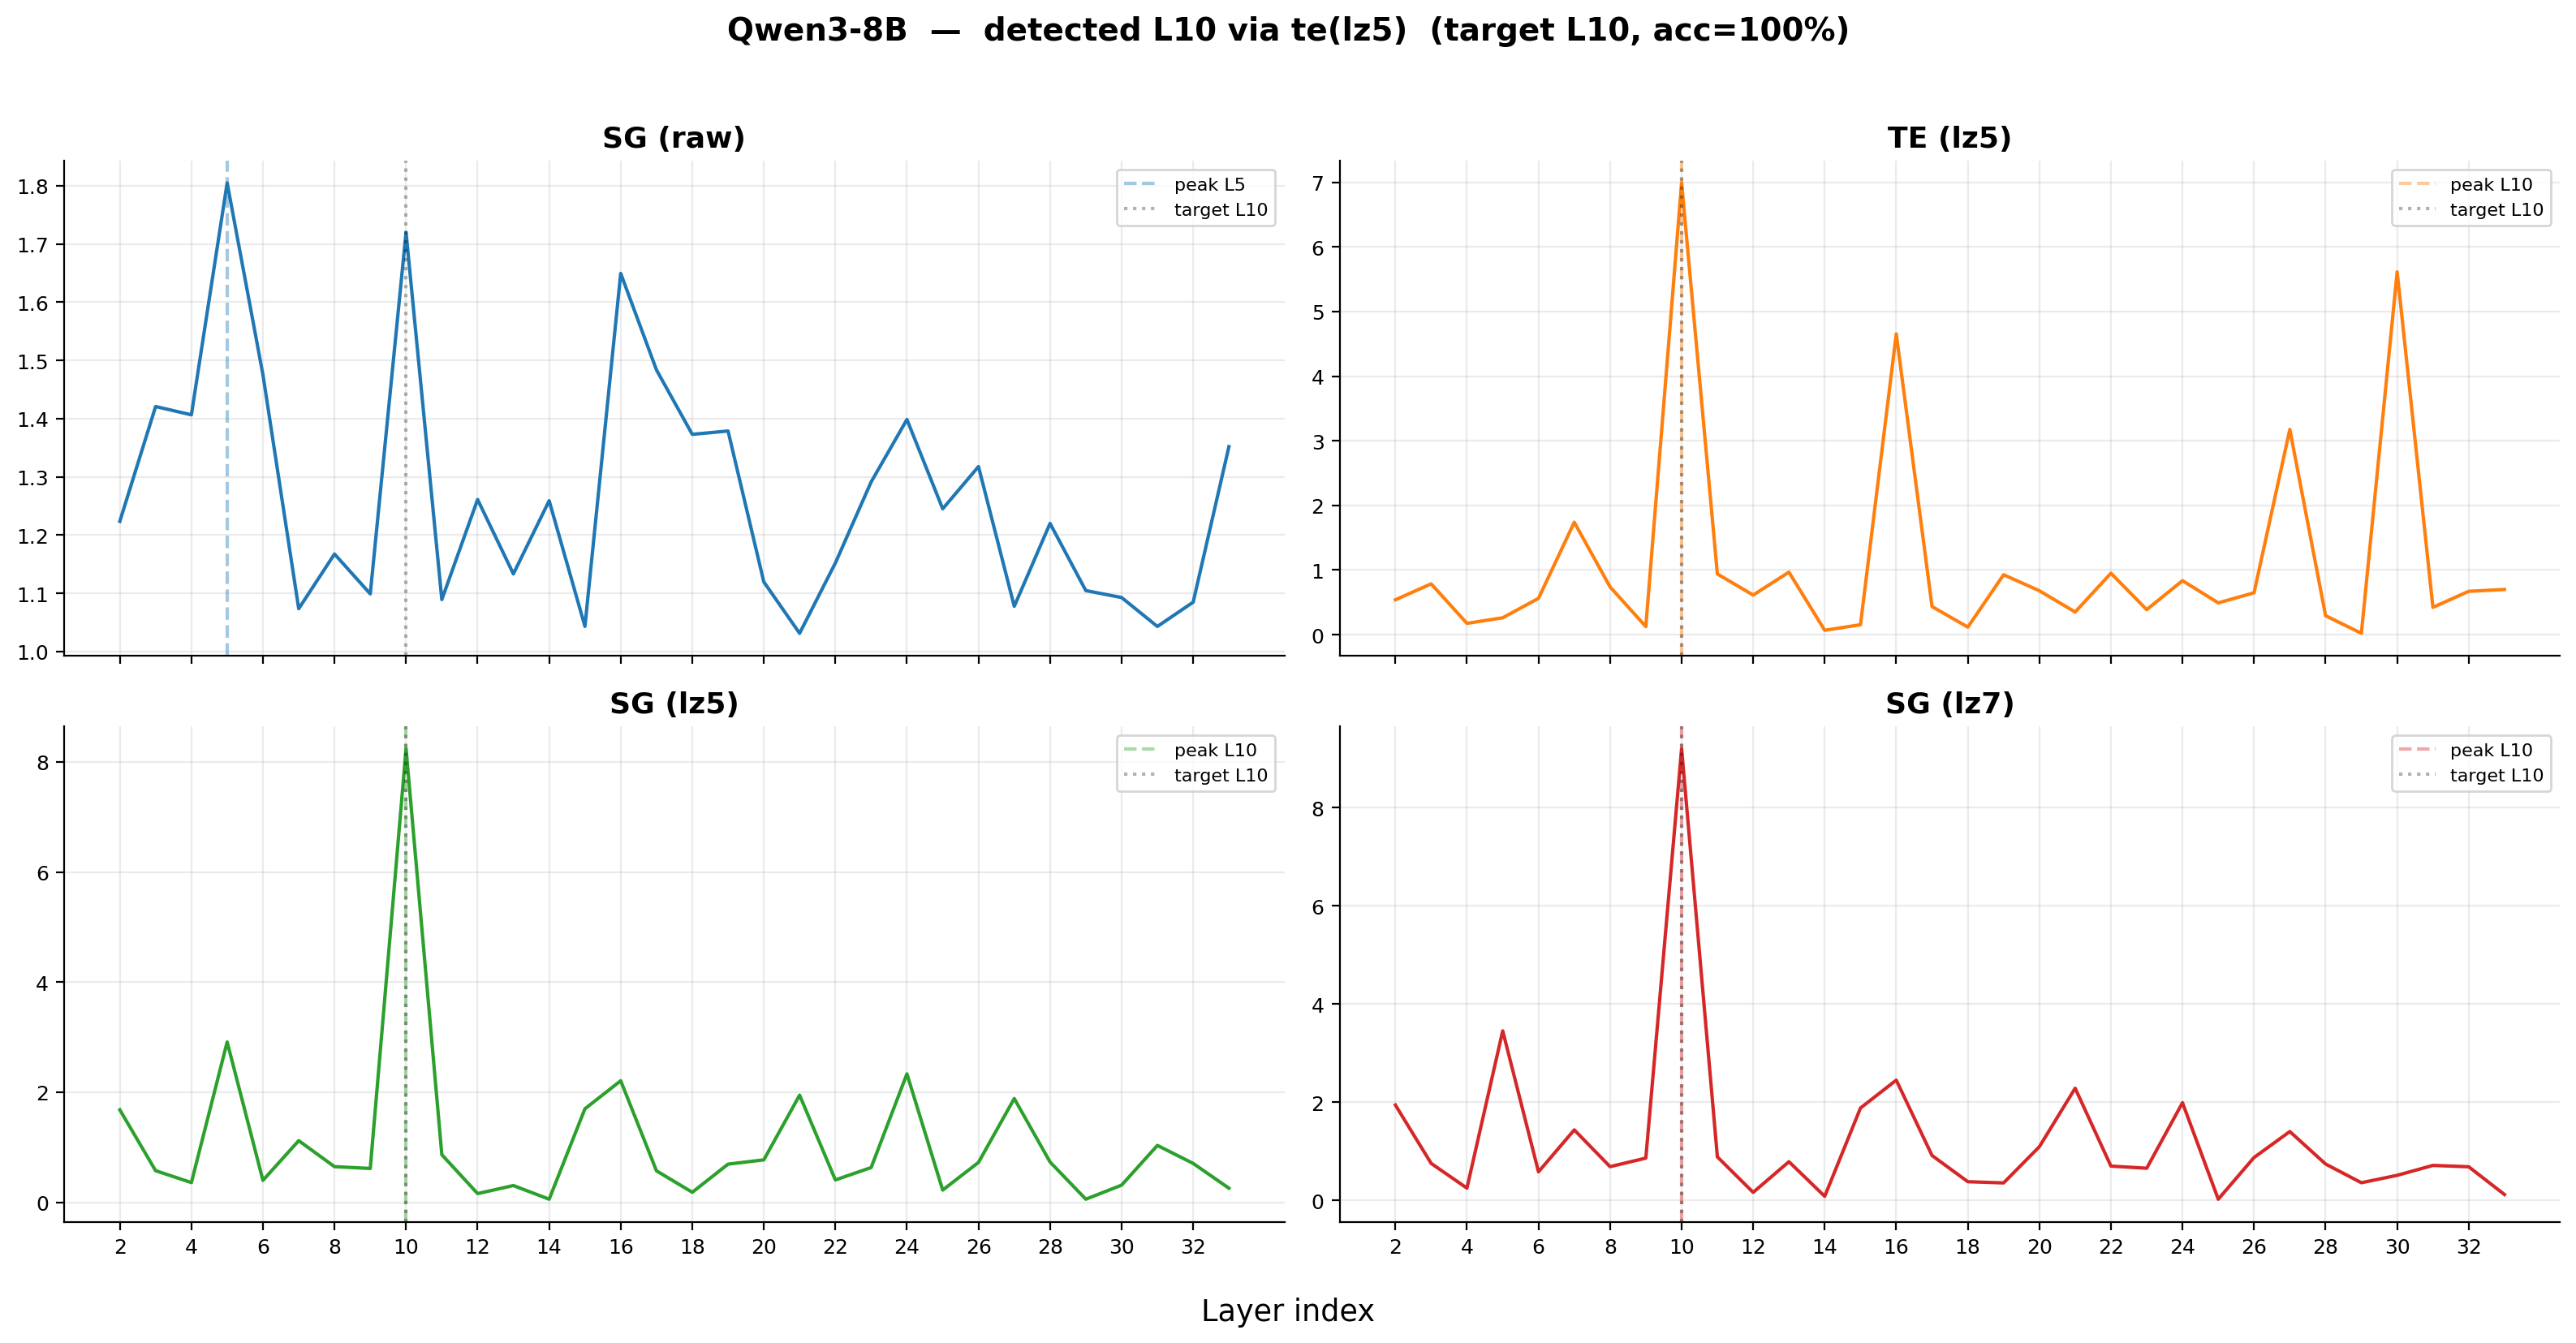

### Qwen3-8B

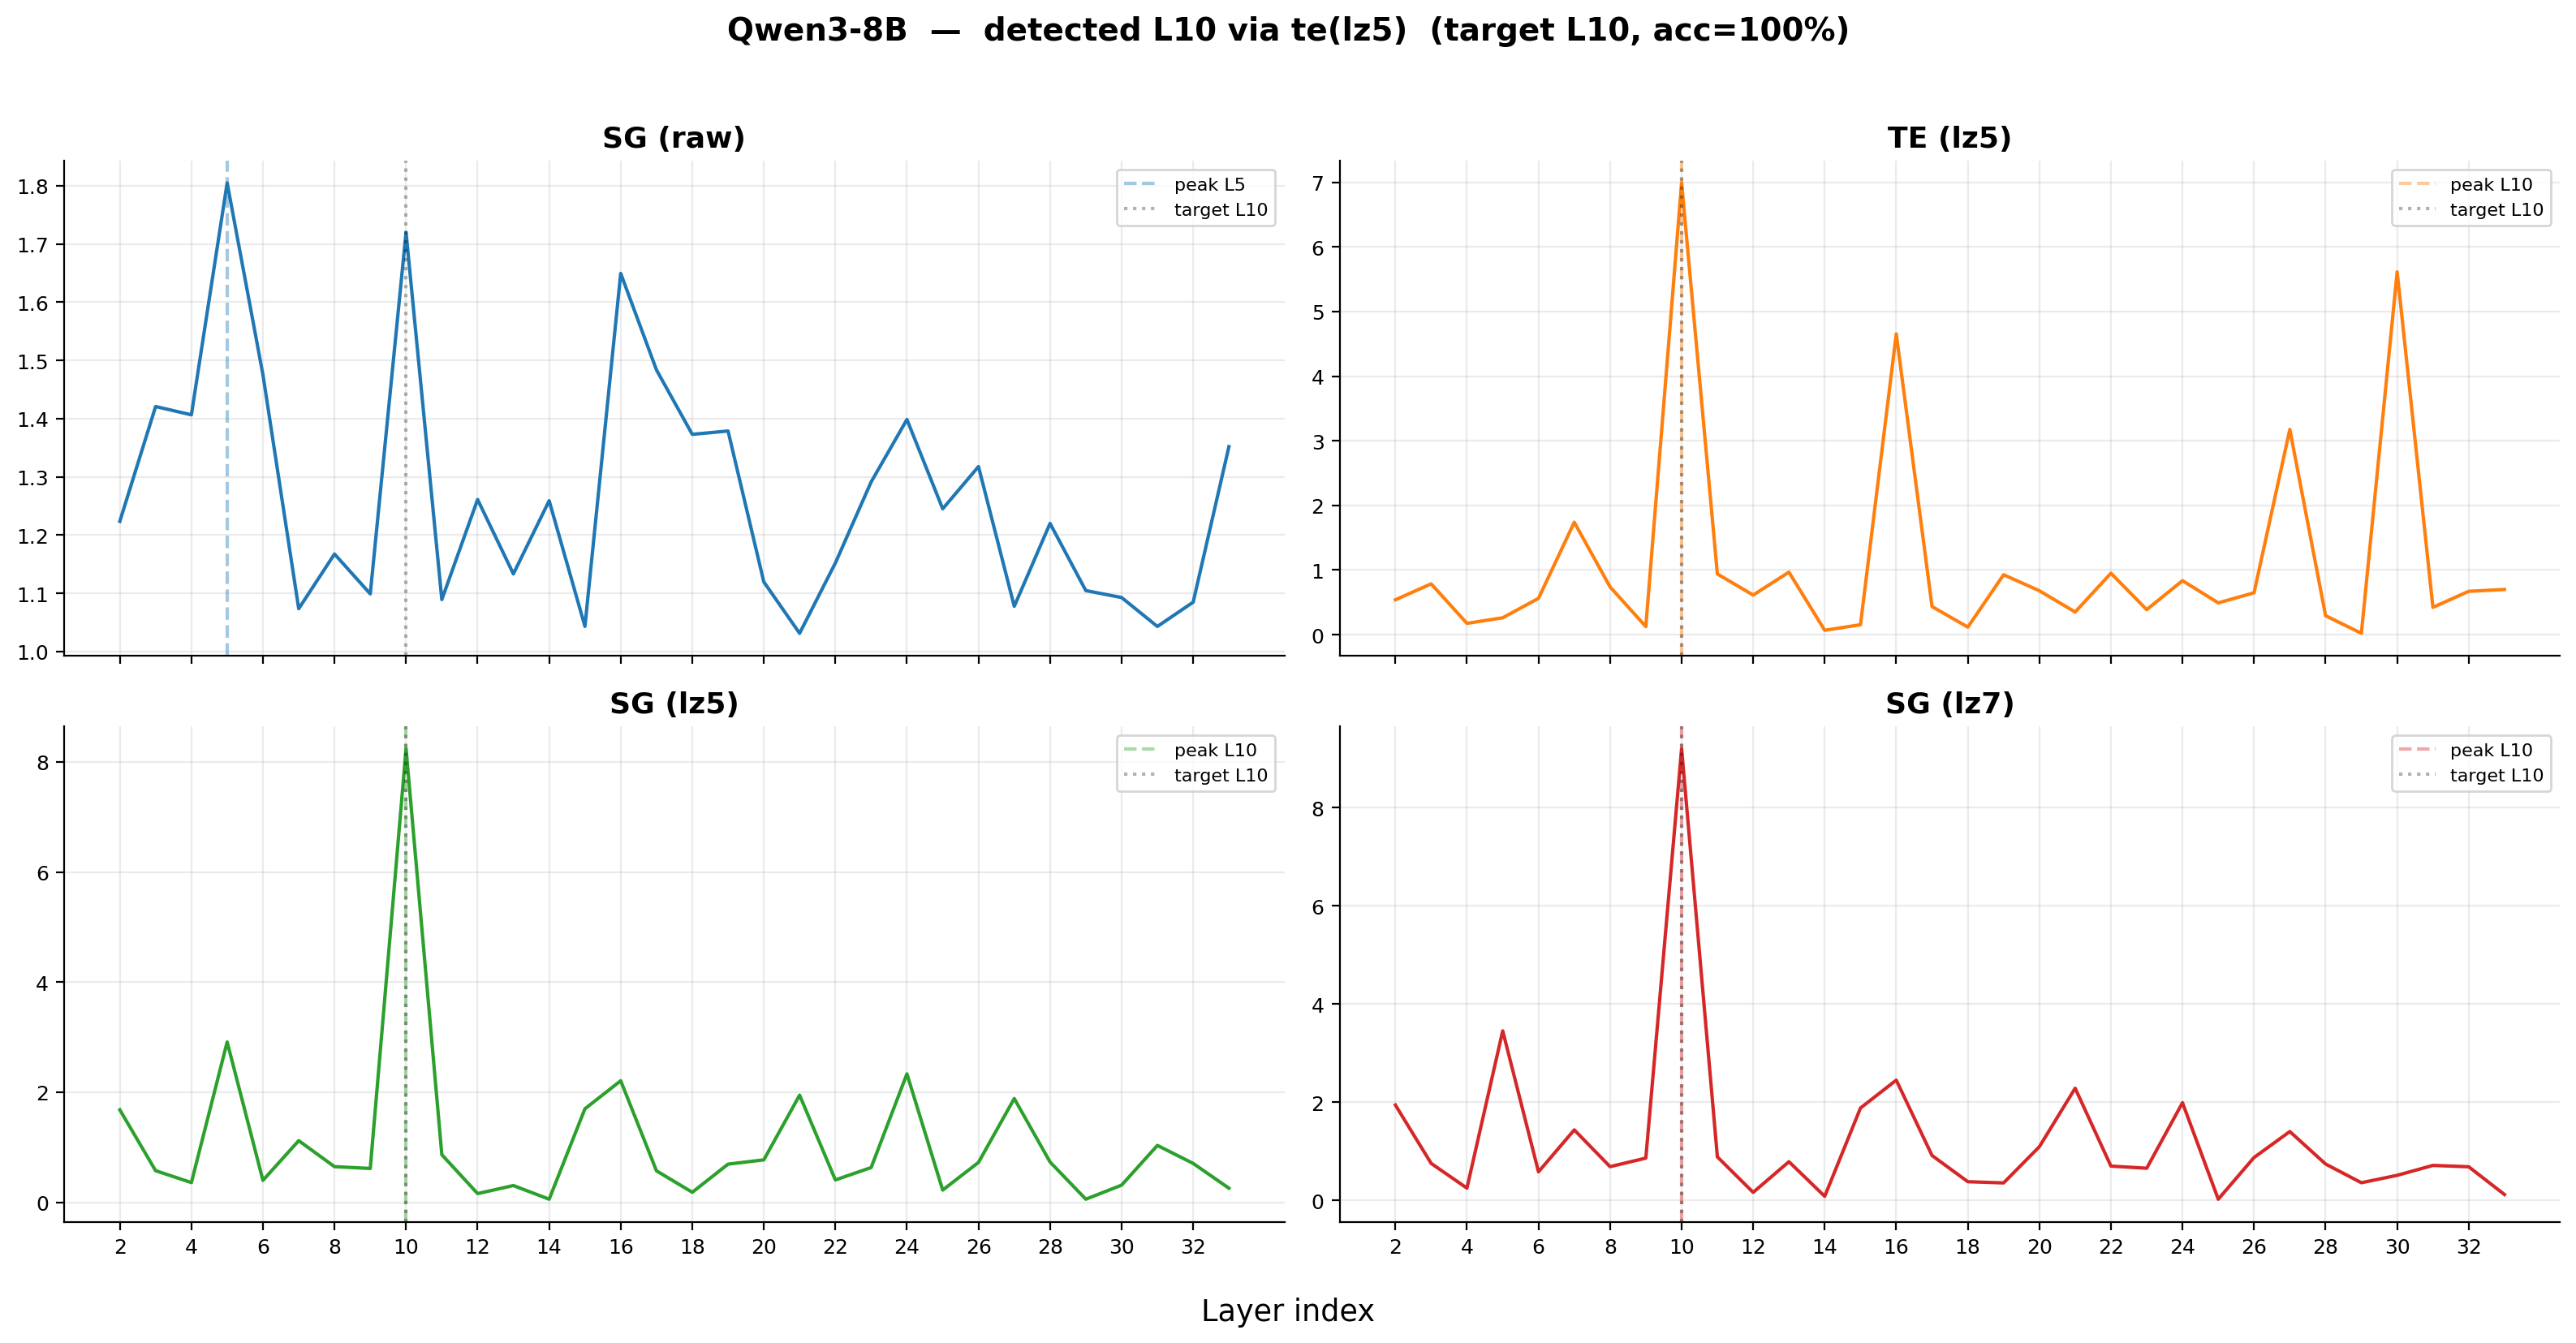

In [8]:
graph_dir = PROJECT_ROOT / "detector" / "graphs"
for r in all_results:
    short = r["model"].split("/")[-1] if "/" in r["model"] else r["model"]
    safe = short.replace("/", "_").replace(" ", "_")
    img_path = graph_dir / f"signals_{safe}.png"
    if img_path.exists():
        display(Markdown(f"### {short}"))
        display(Image(filename=str(img_path), width=900))
    else:
        print(f"  [no graph for {short}]")

## 3. Summary Accuracy

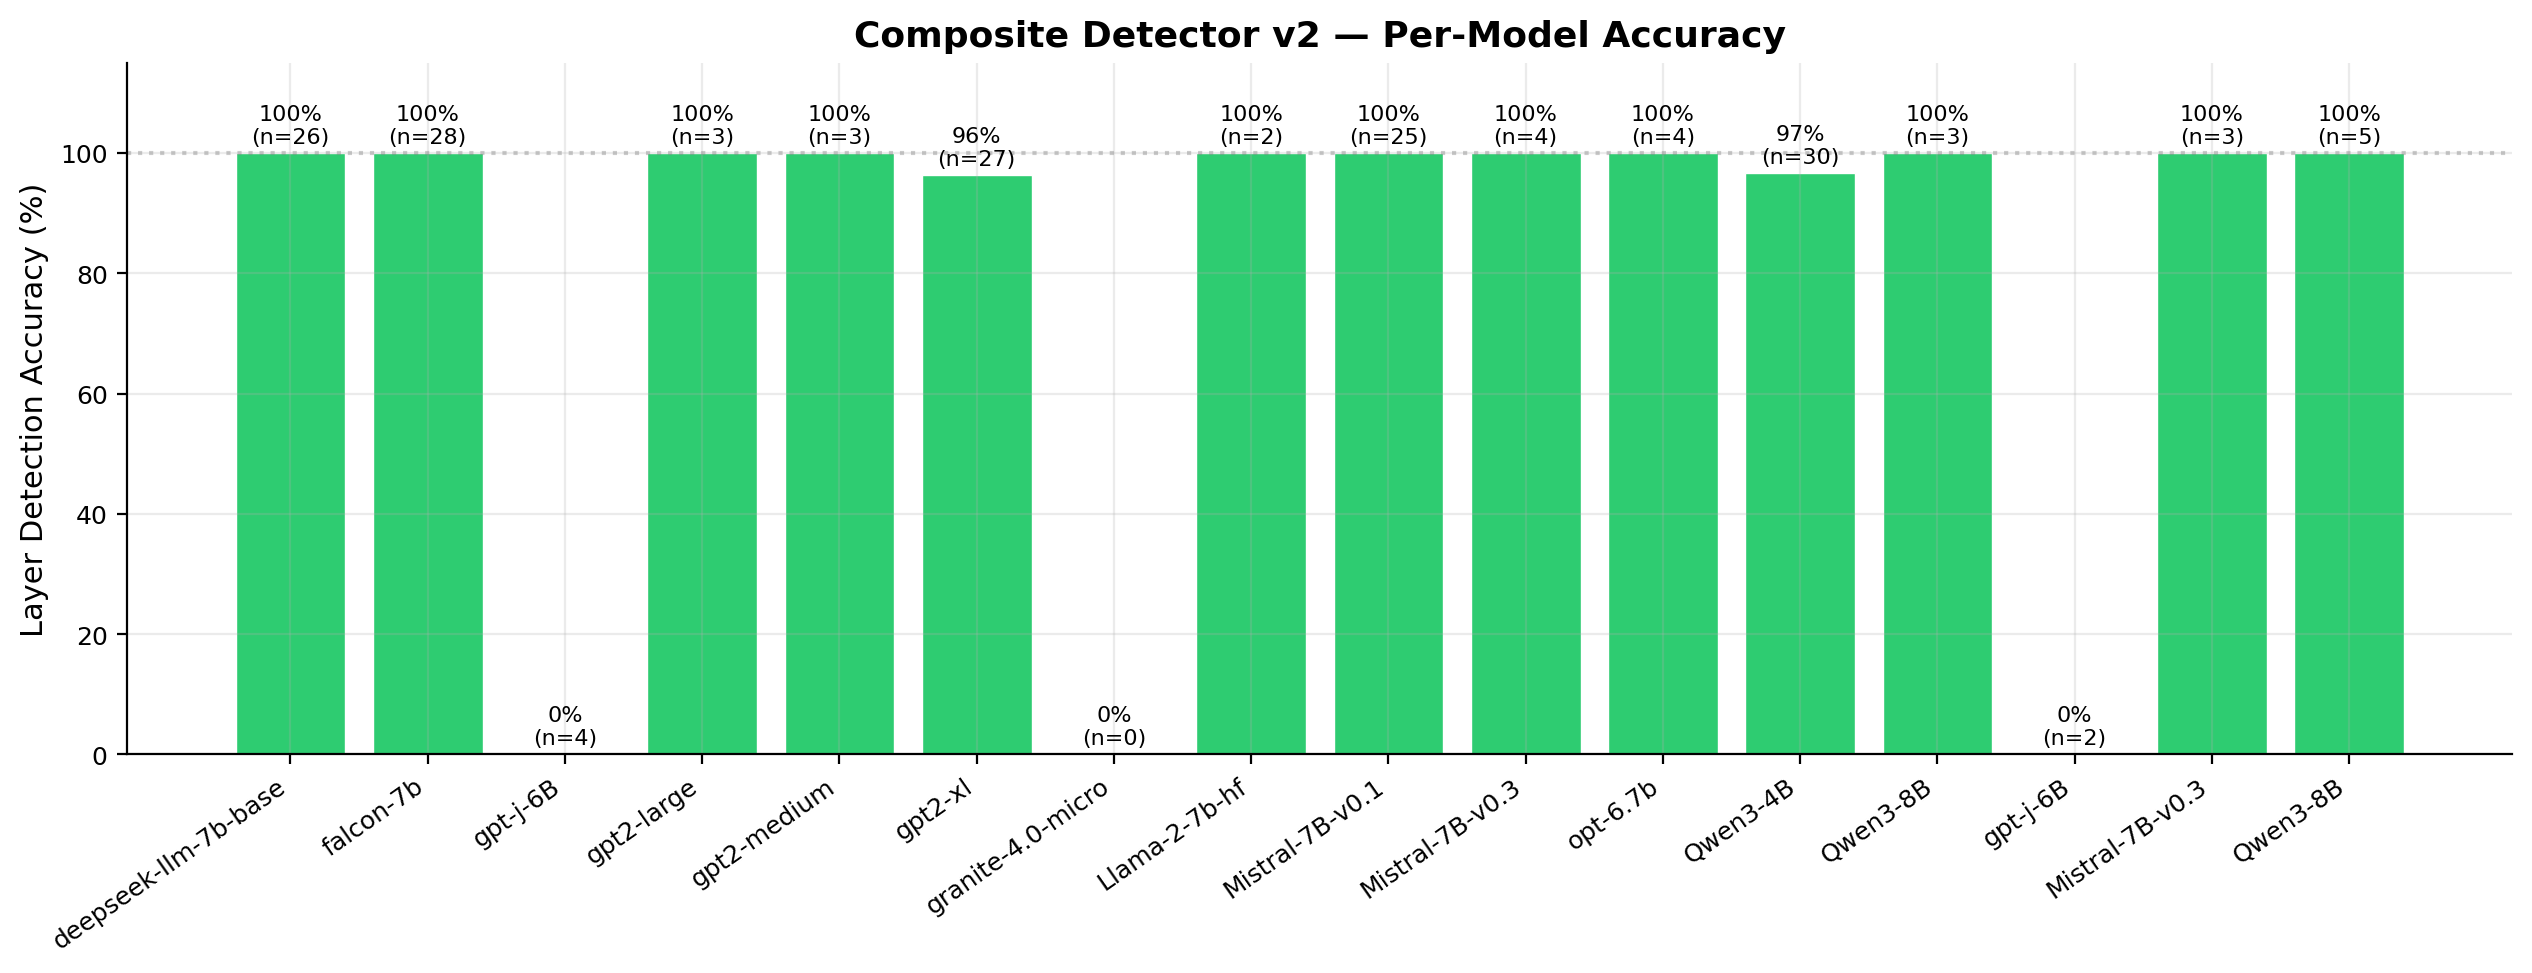

In [9]:
img = graph_dir / "summary_accuracy.png"
if img.exists():
    display(Image(filename=str(img), width=900))
else:
    plot_summary_table(all_results)

## 4. Method Breakdown

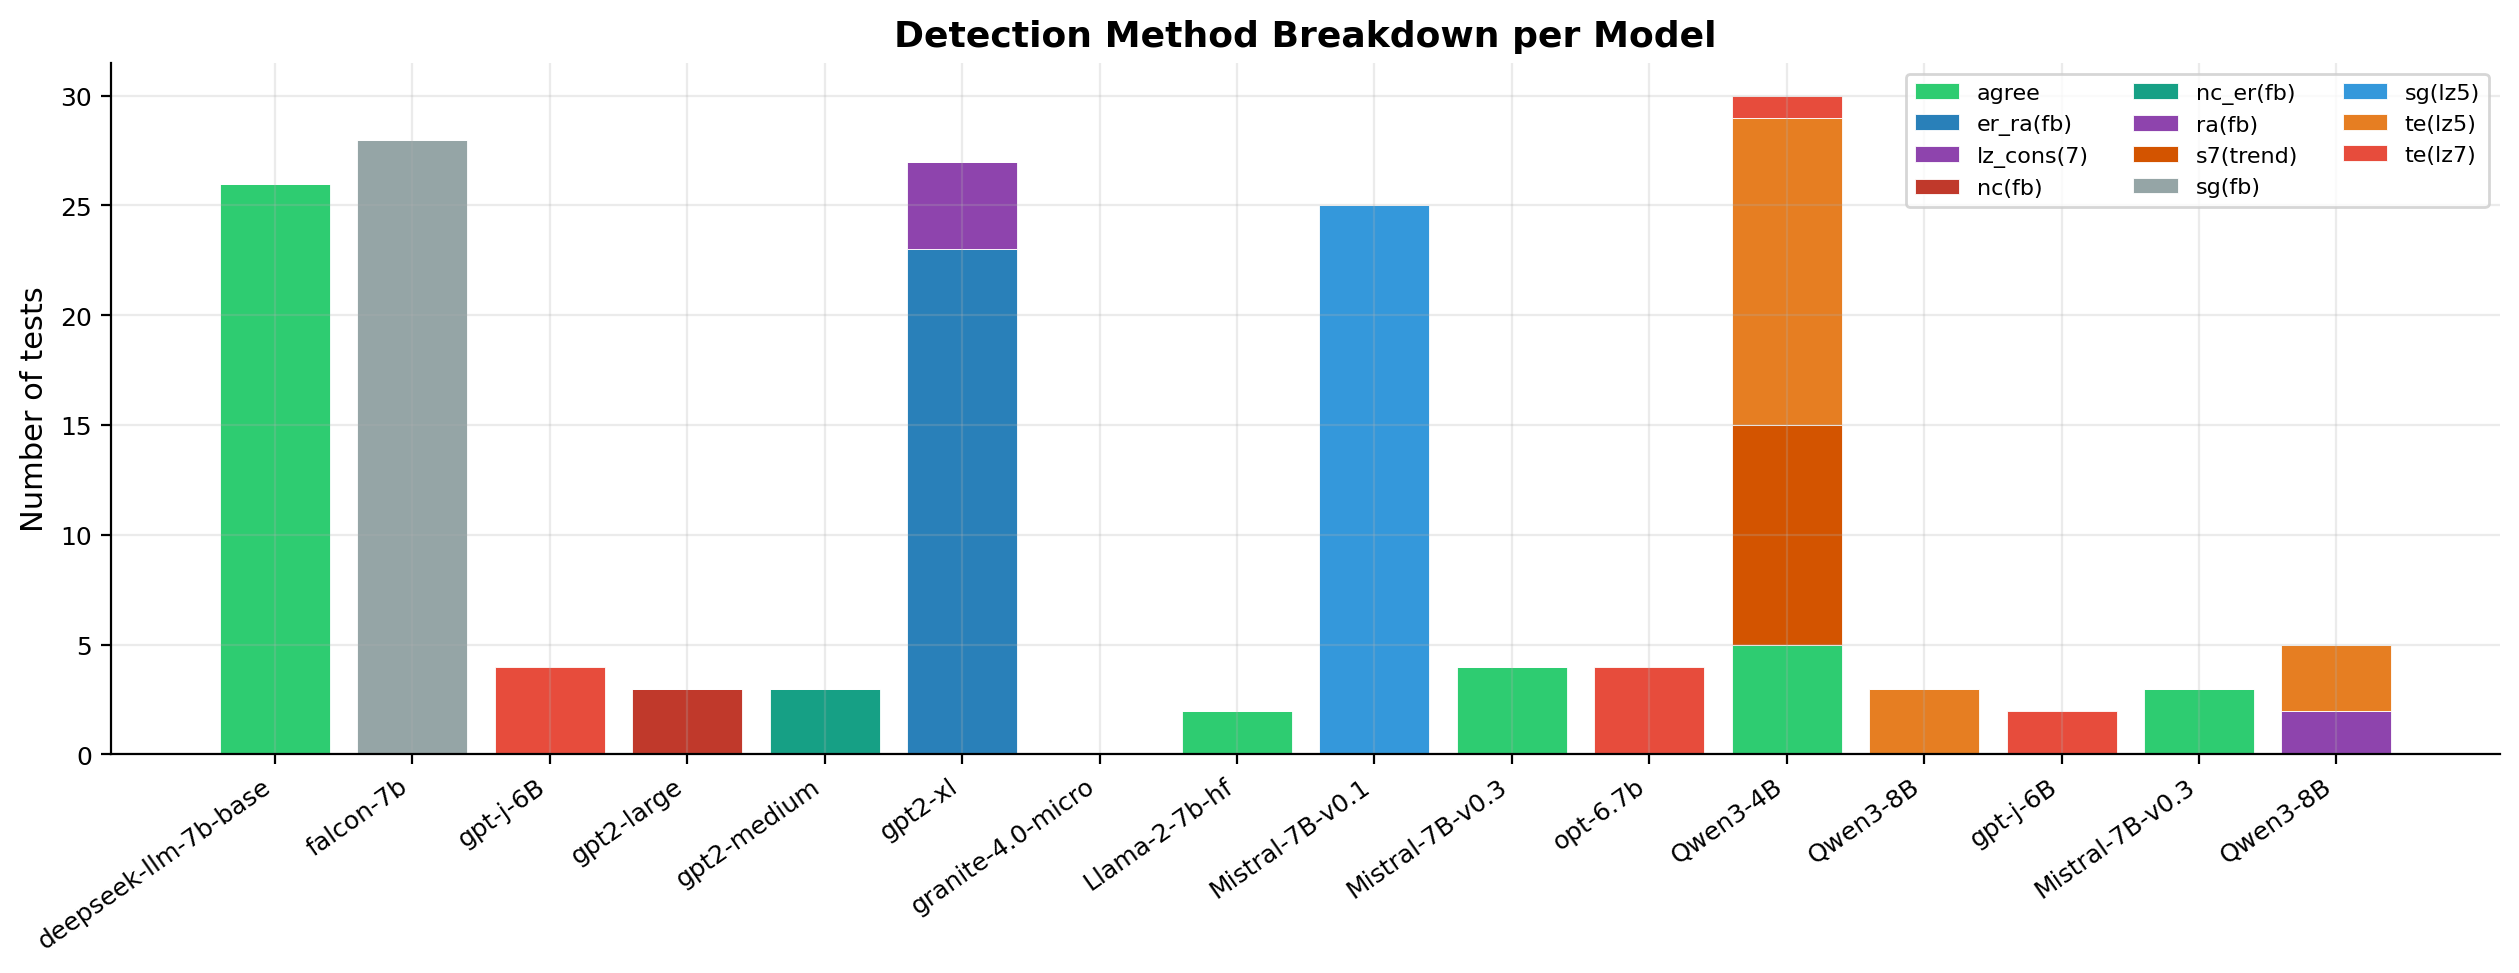

In [10]:
img = graph_dir / "method_breakdown.png"
if img.exists():
    display(Image(filename=str(img), width=900))
else:
    plot_method_breakdown(all_results)

## 5. Top-K Sensitivity Analysis

Instead of always picking the single highest peak (top-1), what if we consider
the top-K peaks per signal and check if the correct layer appears among them?

This measures how "close" each signal gets even when the top-1 is wrong.

In [11]:
def topk_accuracy(all_results, k_values=[1, 2, 3, 5], trim=TRIM,
                  max_tests_per_run=MAX_TESTS_PER_RUN):
    """For each signal and each k, compute: in how many tests does the
    true target appear in the top-k peaks of that signal?"""
    signals = ["spectral_gap", "top1_energy", "norm_cv", "effective_rank",
               "row_alignment", "spectral_entropy"]
    transforms = {
        "raw": lambda vals: vals,
        "lz5": lambda vals: np.abs(local_zscore(vals, 5)),
        "lz7": lambda vals: np.abs(local_zscore(vals, 7)),
        "curv": lambda vals: _curvature(vals),
    }

    results = {}
    for sig in signals:
        for tname, tfn in transforms.items():
            key = f"{sig[:6]}_{tname}"
            results[key] = {k: 0 for k in k_values}
            results[key]["total"] = 0

    for r in all_results:
        path = Path(r["path"])
        target = r["target_layer"]
        with open(path) as f:
            data = json.load(f)

        used_tests = 0
        for t in data.get("tests", []):
            if t.get("error") or not t.get("rome", {}).get("success", True):
                continue
            if max_tests_per_run is not None and used_tests >= max_tests_per_run:
                break
            lf = t["blind_detection"]["layer_features"]
            layers = sorted(lf.keys(), key=int)
            n = len(layers)
            lo, hi = trim, n - trim
            if hi <= lo:
                continue
            eval_layers = [int(l) for l in layers[lo:hi]]

            for sig in signals:
                full = np.array([lf[l][sig] for l in layers])
                for tname, tfn in transforms.items():
                    vals = tfn(full)[lo:hi]
                    key = f"{sig[:6]}_{tname}"
                    results[key]["total"] += 1
                    # Top-k indices
                    ranked = np.argsort(vals)[::-1]
                    for k in k_values:
                        topk_layers = [eval_layers[i] for i in ranked[:k]]
                        if target in topk_layers:
                            results[key][k] += 1
            used_tests += 1

    return results

k_values = [1, 2, 3, 5]
if RUN_TOPK_ANALYSIS:
    topk = topk_accuracy(all_results, k_values)
else:
    topk = {}
    print("Top-K analysis skipped. Set RUN_TOPK_ANALYSIS = True to run it.")

# Display as table
if topk:
    print(f"{'Signal+Transform':<22s}", end="")
    for k in k_values:
        print(f"  {'top-'+str(k):>8s}", end="")
    print(f"  {'total':>6s}")
    print("-" * 60)

    for key in sorted(topk.keys()):
        total = topk[key]["total"]
        if total == 0:
            continue
        print(f"  {key:<20s}", end="")
        for k in k_values:
            acc = topk[key][k] / total
            print(f"  {acc:>7.1%}", end="")
        print(f"  {total:>6d}")

Top-K analysis skipped. Set RUN_TOPK_ANALYSIS = True to run it.


### Top-K for GPT models only

In [12]:
gpt_models = ["gpt-j", "gpt2-xl", "gpt2-large", "gpt2-medium"]
gpt_results = [r for r in all_results
                if any(g in r["model"].lower() for g in gpt_models)]

topk_gpt = {}
if RUN_TOPK_ANALYSIS and gpt_results:
    topk_gpt = topk_accuracy(gpt_results, k_values)

    print(f"{'Signal+Transform':<22s}", end="")
    for k in k_values:
        print(f"  {'top-'+str(k):>8s}", end="")
    print(f"  {'total':>6s}")
    print("-" * 60)

    for key in sorted(topk_gpt.keys()):
        total = topk_gpt[key]["total"]
        if total == 0:
            continue
        print(f"  {key:<20s}", end="")
        for k in k_values:
            acc = topk_gpt[key][k] / total
            print(f"  {acc:>7.1%}", end="")
        print(f"  {total:>6d}")

### Top-K Accuracy Heatmap

In [13]:
if RUN_TOPK_ANALYSIS and (topk or topk_gpt):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, (title, data) in zip(axes, [("All Models", topk),
                                          ("GPT Models Only", topk_gpt)]):
        if not data:
            ax.set_visible(False)
            continue

        keys = sorted(k for k in data.keys() if data[k].get("total", 0) > 0)
        if not keys:
            ax.set_visible(False)
            continue
        matrix = np.array([[data[k][kv] / data[k]["total"]
                            for kv in k_values] for k in keys])

        im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
        ax.set_xticks(range(len(k_values)))
        ax.set_xticklabels([f"top-{k}" for k in k_values])
        ax.set_yticks(range(len(keys)))
        ax.set_yticklabels(keys, fontsize=8)
        ax.set_title(title, fontweight="bold")

        for i in range(len(keys)):
            for j in range(len(k_values)):
                ax.text(j, i, f"{matrix[i,j]:.0%}", ha="center", va="center",
                        fontsize=7, color="black" if matrix[i,j] > 0.4 else "white")

        plt.colorbar(im, ax=ax, shrink=0.8, label="Accuracy")

    plt.tight_layout()
    graph_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(graph_dir / "topk_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {graph_dir / 'topk_heatmap.png'}")
else:
    print("Top-K heatmap skipped.")

Top-K heatmap skipped.


## 6. Failure Analysis

In [14]:
failures = [(r, t) for r in all_results for t in r["results"] if not t["hit"]]
if failures:
    print(f"Total failures: {len(failures)}\n")
    for r, t in failures:
        short = r["model"].split("/")[-1]
        info = t.get("info", {})
        override = info.get("v5_override", {})
        override_str = f" (override from L{override['from']} {override.get('v5_method','')})" if override else ""
        print(f"  {short:<20s} test#{t['test_idx']:2d}  "
              f"target=L{t['target']:2d}  detected=L{t['detected']:2d}  "
              f"method={t['method']}{override_str}")
else:
    print("No failures!")

No failures!


## 7. Per-Model Detail Tables

In [ ]:
for r in all_results:
    short = r["model"].split("/")[-1] if "/" in r["model"] else r["model"]
    if r["accuracy"] == 1.0:
        continue  # Skip perfect models
    print(f"\n{'='*60}")
    print(f"{short}  —  {r['correct']}/{r['n_tests']} ({r['accuracy']:.0%})")
    print(f"{'='*60}")
    for t in r["results"]:
        mark = "✓" if t["hit"] else "✗"
        print(f"  {mark} test#{t['test_idx']:2d}  "
              f"target=L{t['target']:2d}  detected=L{t['detected']:2d}  "
              f"method={t['method']}")

: 